In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


## 数据加载

In [26]:
import unicodedata  # 用于处理Unicode字符，比如去除重音符号
import re           # 正则表达式，用于处理文本的清洗
from sklearn.model_selection import train_test_split  # 用于划分训练集和测试集

# 西班牙语中包含特殊字符和带重音的字母
# 我们需要将Unicode字符转换为ASCII，从而简化字符集，提高后续处理效率
def unicode_to_ascii(s):
    """
    将Unicode字符串s转换为ASCII字符串。
    具体操作是先通过NFD方式将字符分解（例如á会被分为a和´），
    然后移除所有类别是重音符号(Mn，Mark, Nonspacing)的字符，
    最终返回仅包含ASCII可表示的字符的新字符串。
    
    参数:
        s (str): 输入的Unicode字符串
    返回:
        str: 转换后的ASCII字符串
    """
    # NFD分解后，过滤掉所有类别不是Mn(重音符)的字符
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# 测试该函数，分别用英文和带有西班牙语重音符号的句子
# u前缀表示字符串是Unicode字符串
en_sentence = u"May I borrow this book?"          # 英文原始句子
sp_sentence = u"¿Puedo tomar prestado este libro?" # 西班牙语句子，包含倒问号等特殊字符

# 打印ASCII转换结果
print(unicode_to_ascii(en_sentence))   # 期望输出: May I borrow this book?
print(unicode_to_ascii(sp_sentence))   # 期望输出: ?Puedo tomar prestado este libro?


May I borrow this book?
¿Puedo tomar prestado este libro?


In [27]:
def preprocess_sentence(w):
    """
    对输入的句子w进行标准化和清洗处理，步骤如下：
    1. 全部转换为小写，并去除前后多余的空格。
    2. 将Unicode字符转换为ASCII，去除重音等特殊符号，统一西班牙语等特殊字符集。
    3. 在每个标点符号（. ? ! , ¿）两侧加上空格，避免标点和单词黏连，方便后续分词。
    4. 将除英文字母(a-z, A-Z)和指定标点符号（. ? ! , ¿）之外的所有字符替换为一个空格，过滤无用字符。
    5. 多个连续的空格合并为一个空格，保证干净整齐的文本格式。
    6. 再次去除首尾空格，确保句首和句尾没有多余空格。
    :param w: 输入的原始句子（字符串）
    :return: 经过上述清洗和格式化处理的新句子（字符串）
    """
    # 步骤1和2：变为全小写并去除首尾空格，同时转换为ASCII码，即去掉所有重音和修饰符
    w = unicode_to_ascii(w.lower().strip())

    # 步骤3：在每个指定标点（. ? ! , ¿）两侧加上空格，方便后续分词
    # 例如："hello." -> "hello . "
    # 这里\1为分组（即匹配到的标点）本身，r" \1 "表示在前后加空格
    w = re.sub(r"([?.!,¿])", r" \1 ", w)

    # 步骤4：用空格替换所有英文字母及指定标点以外的字符（比如数字、@、#等都变为空格）
    # 只保留字母a-zA-Z及. ? ! , ¿
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    # 步骤5：将多个连续空格合并成一个空格，防止因为上面替换操作形成一堆空格
    w = re.sub(r'[" "]+', " ", w)

    # 步骤6：再去首尾空格，避免残留空白
    w = w.rstrip().strip()

    return w

# 打印英文句子的处理结果
print(preprocess_sentence(en_sentence))
# 打印西班牙语句子的处理结果
print(preprocess_sentence(sp_sentence))
# 打印西班牙语句子的处理结果（utf-8编码后，'¿'为两个字节）
print(preprocess_sentence(sp_sentence).encode('utf-8'))  #¿是占用两个字节的

may i borrow this book ?
¿ puedo tomar prestado este libro ?
b'\xc2\xbf puedo tomar prestado este libro ?'


Dataset

In [28]:
#zip例子
a = [[1,2],[4,5],[7,8]]
sample,label = zip(*a)
print(sample)
print(label)

(1, 4, 7)
(2, 5, 8)


In [29]:
# 使用np.random.choice生成一个长度为100的数组split_index1，对每个样本随机赋予"train"或"test"标签
# a参数指定可选元素为"train"和"test"
# replace=True表示可重复抽取，即每个样本都可被标记为"train"或"test"
# p=[0.9, 0.1]表示90%的概率标记为"train"，10%的概率为"test"
# size=100表示一共生成100个标签
split_index1 = np.random.choice(a=["train", "test"], replace=True, p=[0.9, 0.1], size=100)
# 输出生成的训练/测试标签数组，可用于数据集划分查看
split_index1

array(['train', 'test', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'test', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'test', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'train', 'train', 'train', 'train',
       'train', 'test', 'train', 'test', 'train', 'train', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'test',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train', 'train', 'train', 'train', 'train', 'train',
       'train', 'train'], dty

In [30]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

class LangPairDataset(Dataset):
    # 原始数据集的文件路径
    fpath = Path(r"./data_spa_en/spa.txt")  # 数据文件路径
    # 预处理后缓存的路径，避免每次都重新处理原始数据
    # 缓存的作用是加速数据加载，避免每次实例化数据集都重新处理原始文本。
    # 第一次运行时，原始 spa.txt 文件会被分词、清洗，然后以 numpy 数组形式存储到 cache_path 指定的.npy文件中，
    # 以后只需加载缓存文件，无需再读取和预处理原始文本，大幅提升效率，尤其是多次实验时非常有用。
    cache_path = Path(r"./.cache/lang_pair.npy")  # 缓存文件路径
    # 生成一个长度等于语料数据行数的分割索引，9:1概率产生'train'或'test'标签
    # 这里的split_index是一个 shape=(数据集样本数,) 的一维 numpy 数组，每个元素是字符串 "train" 或 "test"，长度与原始数据集的行数（样本数）相同。
    # 例如: array(['train', 'train', 'test', 'train', ..., 'test'], dtype='<U5')
    # 每一行（样本）通过等概率（如p=[0.9,0.1]）标签，决定属于训练集还是测试集。
    split_index = np.random.choice(
        a=["train", "test"],  # 可选标签，train/test
        replace=True,         # 可以有重复
        p=[0.9, 0.1],         # 90%为train，10%为test
        size=118964           # 数据量大小。此处需与原数据集样本行数一致
    )
    def __init__(self, mode="train", cache=False):
        """
        初始化数据集对象。

        参数:
        mode: 'train' 或 'test'，用于指明构造的是什么子集。
        cache: 是否强制重新生成缓存（True时无视已有缓存）。
        """
        if cache or not self.cache_path.exists():
            # 如果指定cache或缓存文件不存在，则需直接读取原始文本文件并处理
            # 这里主要完成：从原始文本文件读取，每一行按`\t`分隔成[源, 目标]对，然后对每个分句进行预处理。
            # 处理结束后用numpy保存字典{"trg": trg（目标语言数组）, "src": src（源语言数组）}到缓存npy文件
            # 1. self.cache_path.parent.mkdir(parents=True, exist_ok=True)：创建缓存文件夹
            # 2. open(self.fpath, ...) as file: 打开原始数据文件（spa.txt）
            # 3. lines = file.readlines()：读取所有行，每行含 源语言句子 和 目标语言句子，用'\t'隔开
            # 4. lang_pair = [[preprocess_sentence(w) for w in l.split('\t')] for l in lines]
            #    - 遍历每一行l，split('\t')分成2部分，对每部分调用preprocess_sentence
            #    - 最终lang_pair变成二维列表：[[trg1, src1], [trg2, src2], ...]
            # 5. trg, src = zip(*lang_pair)：解包二维列表，得到所有目标和源组成的两个元组
            # 6. trg=np.array(trg)，src=np.array(src)：转为numpy数组
            # 7. np.save(self.cache_path, {"trg": trg, "src": src})：以dict方式保存为npy文件
            
            # 创建缓存文件夹，如果其父目录不存在则递归创建（parents=True），已存在时不会报错（exist_ok=True）
            self.cache_path.parent.mkdir(parents=True, exist_ok=True)
            with open(self.fpath, "r", encoding="utf8") as file:
                lines = file.readlines()  # 逐行读取原始语料
                # 对每一行，通过split('\t')获得[目标语句, 源语句]，并用 preprocess_sentence 进行清洗
                # lang_pair 是形如 [[trg1, src1], [trg2, src2], ...] 的二维列表

                # 是的，这里的 w 只会被赋值为每一行用 \t 分割得到的两个字符串之一（目标句和源句），不是单词。
                # 例如 line = "Go.\tVe.\n"，l.split('\t') 得到 ["Go.", "Ve.\n"]，每个 w 就是完整的句子。
                # preprocess_sentence(w) 预处理的是整个句子不是单词。
                lang_pair = [
                    [preprocess_sentence(w) for w in l.split('\t')]
                    for l in lines
                ]
                # 使用zip*解包，分离得到两个元组：trg（目标）和src（来源）
                trg, src = zip(*lang_pair)
                trg = np.array(trg)  # 转为numpy数组，便于后续索引和存储
                src = np.array(src)
                # 把两个数组序列化存为.npy，字典格式，提升处理效率
                print("缓存文件已保存：", self.cache_path)
                np.save(self.cache_path, {"trg": trg, "src": src})
        else:
            # 走缓存（npy），直接读取
            # 这里走npy缓存，直接读出来的数据类型是dict，dict里'trg'和'src'是两个np.ndarray（字符串数组）
            # lang_pair变量其实是dict，然后 trg/src 是 ndarray
            # 举例: lang_pair = {'trg': np.ndarray, 'src': np.ndarray}
            lang_pair = np.load(self.cache_path, allow_pickle=True).item()
            trg = lang_pair["trg"]
            src = lang_pair["src"]

        # 按预先随机划分的 split_index 选出属于 mode 的部分
        # split_index: shape=(总样本数,)，每一行为'train'或'test'，等长于src/trg
        # 这里self.trg和self.src都是按mode选的同一子集
        self.trg = trg[self.split_index == mode]   # 目标语言（英语）
        self.src = src[self.split_index == mode]   # 源语言（西班牙语）

    def __getitem__(self, index):
        """
        获取指定下标处的(source, target)语言样本。
        """
        return self.src[index], self.trg[index]

    def __len__(self):
        """
        返回数据集中样本数量（即源语言序列的数量）。
        """
        return len(self.src)  # 或len(self.trg)，二者长度应一致


# 创建训练集与测试集对象
train_ds = LangPairDataset("train")
test_ds = LangPairDataset("test")

In [31]:
print("source: {}\ntarget: {}".format(*train_ds[-1]))

source: si quieres sonar como un hablante nativo , debes estar dispuesto a practicar diciendo la misma frase una y otra vez de la misma manera en que un musico de banjo practica el mismo fraseo una y otra vez hasta que lo puedan tocar correctamente y en el tiempo esperado .
target: if you want to sound like a native speaker , you must be willing to practice saying the same sentence over and over in the same way that banjo players practice the same phrase over and over until they can play it correctly and at the desired tempo .


In [32]:
for pair in train_ds:
    print(pair[0])
    print(pair[1])
    break

ve .
go .


### Tokenizer

这里有两种处理方式，分别对应着 encoder 和 decoder 的 word embedding 是否共享，这里实现不共享的方案。

In [33]:
# 两本词典是指分别针对源语言（src）和目标语言（trg）分别构建的词到索引（word2idx）和索引到词（idx2word）字典。
# 这是因为在序列到序列（Seq2Seq）任务中，通常输入（encoder部分）和输出（decoder部分）是不同的语言，它们的词表不相同，词的索引分配也互不干扰。
# 这样可确保每种语言的分词、Embedding、预测解码等过程都是独立、不会混淆的。
# 所以需要“各自一套字典”，也就是“两本词典”。


from collections import Counter

def get_word_idx(ds, mode="src", threshold=2):
    """
    构建词表（word2idx/idx2word）的方法。

    参数:
    ds (Dataset): 传入的数据集（通常为训练集）。
    mode (str): "src" 表示源语言，"trg" 表示目标语言，决定从数据集中取第几个字段。
    threshold (int): 词频阈值，出现次数低于该值的 token 不会被加入词表。（实际中立即被覆盖为1）

    返回:
    word2idx (dict): token 到索引的映射。
    idx2word (dict): 索引到 token 的映射。
    """

    # 预设特殊 token，并分配索引：
    word2idx = {
        "[PAD]": 0,     # 填充 token（Padding token），用于补齐序列长度
        "[BOS]": 1,     # 句子开始 token（Begin of sentence）
        "[UNK]": 2,     # 未知 token（Unknown token），词表外词
        "[EOS]": 3,     # 句子结束 token（End of sentence）
    }
    # 反向索引表，索引到token
    idx2word = {value: key for key, value in word2idx.items()}
    index = len(idx2word)  # 下一个可用索引

    threshold = 1  # 保险起见将阈值设置为1（只丢弃出现频率为0的token）

    # 将数据集对应语言的全部句子拼接为一个词字符串，然后按空格切分为词列表
    # mode=="src"时取每个pair的第一个元素（源语言），否则为目标语言
    
    # 这一行代码作用是：将数据集 ds 中指定语言（src 或 trg）的所有句子合并成一个大的字符串，然后以空格为分隔符切分成词（token）列表。
    # 具体解释如下：
    # [pair[0 if mode == "src" else 1] for pair in ds]：遍历数据集 ds 的每个样本对 pair，
    #   如果 mode 为 "src" 就取第一个元素（源语言句子），否则取第二个元素（目标语言句子）。
    # 用 " ".join(...) 将所有句子连接成一串大文本，句子间加空格。
    # 最后用 .split() 以空格为界切分，得到所有词组成的列表 word_list。
    word_list = " ".join([pair[0 if mode == "src" else 1] for pair in ds]).split()

    # 统计词频：Counter返回的是一个字典，键是单词，值是出现次数
    # 会自动去重。Counter(word_list) 本身就统计了每个词出现的次数，counter的每个key只出现一次。
    counter = Counter(word_list)
    print("word count:", len(counter))  # 打印出去重后词的总数

    # 遍历所有词，根据出现次数决定是否加入词表
    for token, count in counter.items():
        if count >= threshold:   # 出现大于等于阈值的词才进入词表
            word2idx[token] = index   # 分配索引
            idx2word[index] = token   # 索引反查
            index += 1                # 下一个可用索引

    return word2idx, idx2word

# 构建源语言（西班牙语）词表。word2idx: {词:编号}，idx2word: {编号:词}
src_word2idx, src_idx2word = get_word_idx(train_ds, "src")  # 源语言词表
# 构建目标语言（英语）词表
trg_word2idx, trg_idx2word = get_word_idx(train_ds, "trg")  # 目标语言词表

word count: 23715
word count: 12500


In [34]:
trg_idx2word[5]

'.'

In [35]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        初始化Tokenizer对象

        参数:
            word2idx (dict): 单词到索引的映射字典。
            idx2word (dict): 索引到单词的映射字典。
            max_length (int): 最大句子长度，超过会被截断（加上BOS/EOS）。
            pad_idx (int): Padding标记的索引。
            bos_idx (int): 句子开始符号的索引。
            eos_idx (int): 句子结束符号的索引。
            unk_idx (int): 未知词的索引。
        """
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.max_length = max_length
        self.pad_idx = pad_idx
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.unk_idx = unk_idx

    def encode(self, text_list, padding_first=False, add_bos=True, add_eos=True, return_mask=False):
        """
        将分词后的句子批量编码为索引，并进行padding，支持前/后补齐。
        
        参数:
            text_list (list[list[str]]): 句子分词后的列表，每个元素是一个分词列表。
            padding_first (bool): 是否前向padding（True: pad加在左边，False: 右边）。
            add_bos (bool): 是否在每句前添加BOS标记。
            add_eos (bool): 是否在每句后添加EOS标记。
            return_mask (bool): 是否返回mask（1代表pad，0代表有效token）。
        返回:
            input_ids: shape=[batch, seq_len]的tensor，每个token为其索引。
            masks: (可选) shape为input_ids相同，pad位置为1，其余为0。
        """
        # 动态计算本批次最大长度，不超过self.max_length
        max_length = min(
            self.max_length,
            add_eos + add_bos + max([len(text) for text in text_list])
        )
        indices_list = []
        for text in text_list:
            # 先截取最大长度（考虑BOS/EOS的占位），映射为索引，词表外用unk替代
            indices = [self.word2idx.get(word, self.unk_idx) for word in text[:max_length - add_bos - add_eos]]
            if add_bos:
                indices = [self.bos_idx] + indices
            if add_eos:
                indices = indices + [self.eos_idx]
            # 根据padding_first参数确定pad方式（前/后补0至指定长度）
            if padding_first:
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        input_ids = torch.tensor(indices_list)
        # 生成mask：pad为1，其余为0，掩码常用于后续损失与attention的mask
        masks = (input_ids == self.pad_idx).to(dtype=torch.int64)
        return input_ids if not return_mask else (input_ids, masks)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        将索引序列反解为文本（单句或批量），可选去除特殊标记
        
        参数:
            indices_list (list[list[int]]): 每个句子的索引序列（支持tensor或list）
            remove_bos (bool): 是否去掉[BOS]
            remove_eos (bool): 是否遇到[EOS]后即终止
            remove_pad (bool): 是否遇到[PAD]后即终止
            split (bool): True返回分词list，False返回拼接的字符串句子
        返回:
            text_list: 解码后字符串/分词数组列表
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")
                if remove_bos and word == "[BOS]":
                    continue  # 跳过BOS
                if remove_eos and word == "[EOS]":
                    break     # 碰到EOS则立即终止（常见于预测解码节点）
                if remove_pad and word == "[PAD]":
                    break     # PAD终止（只留真实内容）
                text.append(word)
            text_list.append(" ".join(text) if not split else text)
        return text_list

# 注：分别为源语言和目标语言建立Tokenizer可减少各自Embedding参数量
src_tokenizer = Tokenizer(word2idx=src_word2idx, idx2word=src_idx2word)  # 源语言Tokenizer
trg_tokenizer = Tokenizer(word2idx=trg_word2idx, idx2word=trg_idx2word)  # 目标语言Tokenizer

# 构造一批dummy数据，测试编码器和mask生成
raw_text = [
    "hello world".split(),
    "tokenize text datas with batch".split(),
    "this is a test".split()
]

# 对raw_text进行编码，右侧补pad，添加BOS/EOS，并返回mask
indices, mask = trg_tokenizer.encode(
    raw_text, 
    padding_first=False,   # pad后填
    add_bos=True, 
    add_eos=True, 
    return_mask=True
)

print("raw text" + '-' * 10)
for raw in raw_text:
    print(raw)
print("mask" + '-' * 10)
for m in mask:
    print(m)
print("indices" + '-' * 10)
for index in indices:
    print(index)


raw text----------
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']
mask----------
tensor([0, 0, 0, 0, 1, 1, 1])
tensor([0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 1])
indices----------
tensor([   1,   16, 3218,    3,    0,    0,    0])
tensor([   1,    2, 3878,    2,  552,    2,    3])
tensor([   1,  117,  235,  103, 2896,    3,    0])


In [36]:
decode_text = trg_tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)
print("decode text"+'-'*10)
for decode in decode_text:
    print(decode)

decode text----------
[BOS] hello world [EOS] [PAD] [PAD] [PAD]
[BOS] [UNK] text [UNK] with [UNK] [EOS]
[BOS] this is a test [EOS] [PAD]


### DataLoader

In [37]:
def collate_fct(batch):
    """
    自定义的批处理（collate）函数，用于DataLoader。
    处理流程:
        - 将batch（一批样本）中的文本内容分成words列表（分词）
        - 编码源语言（src）和目标语言（trg）的句子，添加特殊token（BOS/EOS/PAD），并生成mask
        - 返回包含多项tensor格式结果的字典
    参数:
        batch: List[Tuple[str, str]]
            比如：[(src_sentence1, trg_sentence1), (src_sentence2, trg_sentence2), ...]
    返回:
        一个包含模型输入所需各项的字典
    """

    # 取batch内第0列（源语言句子），对每句进行split分词，得到二维列表
    src_words = [pair[0].split() for pair in batch]  
    # 取batch内第1列（目标语言句子），对每句进行split分词，得到二维列表
    trg_words = [pair[1].split() for pair in batch]  

    # mask用于指示padding的位置，使模型忽略这些填充的部分。一般原则如下：
    # 1. 对encoder输入（源语言句子），需要mask，因为实际输入序列中存在padding。
    #    在self-attention/encoder-decoder attention中，mask可以屏蔽掉PAD token的影响。
    # 2. 对decoder输出标签（也就是ground truth），需要对应的mask，便于计算loss时忽略PAD部分，避免padding影响loss计算。
    # 3. 对decoder的输入（teacher-forcing的目标输入），通常不需要mask，因为解码器生成时主要依赖于输入序列本身，不需要额外对padding位置特殊处理。
    # 总结：凡是会有padding且需要屏蔽padding影响（如encoder输入、loss计算标签），就要加mask；单纯作为解码器输入feeding时可不加mask。

    # 为什么采取这种不同的填充策略
    # 
    # 1. 对encoder输入（源语言），采用的是左侧padding（padding_first=True），主要原因在于部分模型（如Transformer等）对填充位置并不敏感，但左pad更方便做mask以及适配部分旧序列模型（如某些RNN）。
    #
    # 2. 对decoder输入/输出（目标语言）通常采用右侧padding（padding_first=False），这样在自回归生成时，实际target输出的有效内容总是排列在左边，后面的padding不会干扰预测，有利于训练时候mask的处理和解码规约。
    #
    # 3. decoder输入和decoder输出虽然都右pad，但训练decoder的时候通常decoder_input前加BOS，decoder_label后加EOS，这样对齐方式是：
    #    decoder_inputs: <BOS> w1 w2 w3 <PAD> <PAD>
    #    decoder_labels: w1    w2 w3 <EOS> <PAD> <PAD>
    #    这样一一对应，实现teacher forcing。 
    #
    # 总体目的：合理设计padding和特殊token的顺序与位置，能确保loss、mask处理逻辑高效且推理时无歧义。
    

    # encoder输入（源语言）一般在句首加BOS，在句末加EOS，这样做的目的是：
    #   1. BOS可以让模型更明确地标记每个输入序列的起始，有助于模型捕捉序列开始时的重要上下文。
    #   2. EOS用于指示输入序列的终止，让模型知道何时停止关注后续内容，提升对句子边界的感知能力。
    #   3. 对序列建模（比如 RNN/Transformer）来说，明确的序列起止标记能帮助模型区分不同句子间的内容，减少截断或拼接时的信息混淆。
    # 如果缺了BOS/EOS，模型在处理接续多个输入时可能丢失句子边界的信息，不利于正确抽取特征或生成对齐的表示。
    
    # 那BOS，EOS的添加为何不同，为什么要这样设计呢
    # 
    # 1. 在encoder输入（源语言）上，通常在句首加BOS、句尾加EOS，以便模型明确定义序列边界，有助于捕捉上下文边界信息。
    #    这样做也方便与decoder的对齐处理（尤其是在做alignment或copy机制等）。BOS/EOS都加，无歧义。
    #
    # 2. 对decoder输入（teacher forcing时的目标输入），我们只在句首加BOS，不加EOS。
    #    这样做的原因：decoder在生成第t个词时，需要看到前t-1个目标词（即<bos> w1 w2 ...），这样预测下一个词w_t。
    #    不加EOS可以保证decoder输入和输出严格对齐（shift一位）。
    #
    # 3. 对decoder输出（即训练标签），不加BOS，句尾加EOS。
    #    这样设计原因是：让模型显式学会在句子末尾输出<EOS>，而标签不需要BOS。
    #    换句话说，decoder输入和输出在时间轴上是错开一位的，保证每步decoder输入和预测的输出严格对应并可对齐，
    #    这样teacher forcing和mask的处理才方便。
    #
    # 总结：
    #   encoder_inputs: <BOS> w1 w2 ... wn <EOS>
    #   decoder_inputs: <BOS> y1 y2 ... ym
    #   decoder_labels:      y1 y2 ... ym <EOS>
    #   每一位置的数据相互shift一位，使模型能学会正确生成起始和终止标记，并且方便计算loss。


    # 对源语言（encoder输入）编码:
    #  - 在前面加BOS，后面加EOS
    #  - pad补齐到同一长度，pad在序列左侧（padding_first=True）
    encoder_inputs, encoder_inputs_mask = src_tokenizer.encode(
        src_words, 
        padding_first=True,   # pad在前
        add_bos=True,        # 增加BOS
        add_eos=True,        # 增加EOS
        return_mask=True     # 返回padding mask
    )

    # 对目标语言（decoder输入）编码:
    #  - 在前面加BOS，不加EOS
    #  - pad补齐到同一长度，pad在序列右侧（padding_first=False）
    #  - 不需要mask
    decoder_inputs = trg_tokenizer.encode(
        trg_words, 
        padding_first=False,  # pad在后
        add_bos=True,         # 增加BOS
        add_eos=False,        # 不加EOS
        return_mask=False     # 不返回mask
    )

    # 对目标语言（decoder输出标签）编码:
    #  - 不加BOS，在结尾加EOS
    #  - pad补齐到同一长度，pad在序列右侧（padding_first=False）
    #  - 需要mask
    decoder_labels, decoder_labels_mask = trg_tokenizer.encode(
        trg_words, 
        padding_first=False,  # pad在后
        add_bos=False,        # 不加BOS
        add_eos=True,         # 增加EOS
        return_mask=True      # 返回mask
    )

    # 返回dict字典，包含所有模型训练和推理所需的输入
    return {
        # encoder输入的句子序列（带token id）
        "encoder_inputs": encoder_inputs.to(device=device),
        # encoder输入对应的padding mask
        "encoder_inputs_mask": encoder_inputs_mask.to(device=device),
        # decoder输入序列（带token id），用于训练teacher-forcing
        "decoder_inputs": decoder_inputs.to(device=device),
        # decoder输出标签序列（带token id），用于计算loss
        "decoder_labels": decoder_labels.to(device=device),
        # decoder输出标签对应的有效mask，mask用于去除padding对loss的影响
        "decoder_labels_mask": decoder_labels_mask.to(device=device), 
    }


In [38]:
# 本代码块演示如何基于上面定义的collate_fct对train_ds中的样本进行批量数据准备和封装处理，并详细输出每个字段含义和shape。
# collate_fct会自动对一批（这里batch_size=2）样本，将原始句子分别编码为适合模型输入的张量，包括padding、加BOS/EOS等，并组合为字典。

sample_dl = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fct)

# 每次循环取一批数据（batch），collate_fct会负责把原始样本打包（编码、补pad、mask等），
# 每个batch为一个dict，包含模型训练和推理需要的5个字段：
#  "encoder_inputs", "encoder_inputs_mask", "decoder_inputs", "decoder_labels", "decoder_labels_mask"

# 由于DataLoader设置了shuffle=True，每次执行得到的内容可能不一样（样本顺序不同）。
for batch in sample_dl:
    print("当前batch的全部字段及对应shape和内容如下（由collate_fct处理生成）：\n")
    for key, value in batch.items():
        print(f"{key}: 形状 {value.shape}")
        print(value)
        print("\n------\n")
    print("说明：")
    print("- encoder_inputs: 源语言token id序列，已添加BOS和EOS，并pad到统一长度，适用于Encoder输入。")
    print("- encoder_inputs_mask: encoder_inputs对应的pad位置mask（值为0是pad，1是有效token），方便忽略padding。")
    print("- decoder_inputs: 目标语言token id序列，已加BOS（无EOS），pad到统一长度，作为Decoder输入（Teacher Forcing）。")
    print("- decoder_labels: 目标语言token id序列（去掉BOS，加上EOS），pad到统一长度，作为Decoder的输出标签。")
    print("- decoder_labels_mask: decoder_labels的mask，用于loss时去除padding区域的影响。")
    break  # 只输出第一个batch示例

当前batch的全部字段及对应shape和内容如下（由collate_fct处理生成）：

encoder_inputs: 形状 torch.Size([2, 9])
tensor([[   0,    1,   55,   67, 1056,  306,   50,    5,    3],
        [   1,   92, 5604,   50, 2622,  489, 3758,    5,    3]])

------

encoder_inputs_mask: 形状 torch.Size([2, 9])
tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]])

------

decoder_inputs: 形状 torch.Size([2, 9])
tensor([[   1,   17,   32,  516,   30, 1088, 1577,    5,    0],
        [   1,   47, 2976,  689, 5400, 2238,  634,   29,    5]])

------

decoder_labels: 形状 torch.Size([2, 9])
tensor([[  17,   32,  516,   30, 1088, 1577,    5,    3,    0],
        [  47, 2976,  689, 5400, 2238,  634,   29,    5,    3]])

------

decoder_labels_mask: 形状 torch.Size([2, 9])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]])

------

说明：
- encoder_inputs: 源语言token id序列，已添加BOS和EOS，并pad到统一长度，适用于Encoder输入。
- encoder_inputs_mask: encoder_inputs对应的pad位置mask（值为0是pad，1是有效token），方便忽略padding。
- decoder_inputs: 目

## 定义模型

In [39]:
class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        """
        Encoder模块（多层GRU为编码器）:
            - vocab_size: 输入词表的大小（即有多少种token）
            - embedding_dim: 词嵌入维度，输入token首先映射为embedding向量，再送入GRU
            - hidden_dim: 隐状态维度，每一个GRU单元输出的向量长度
            - num_layers: GRU堆叠的层数
        """
        super().__init__()
        # nn.Embedding层：把token id映射为embedding向量，shape: [batch, seq_len] → [batch, seq_len, embedding_dim]
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # GRU层: 输入embedding序列，输出每一步隐藏状态和最后一层最后时刻的hidden
        # batch_first=True: 输入和输出的第一个维度是batch
        self.gru = nn.GRU(
            embedding_dim,           # 输入特征维度
            hidden_dim,              # GRU隐藏单元输出的特征维度
            num_layers=num_layers,   # 堆叠GRU层数
            batch_first=True         # 输入形状为[batch, seq, feat]
        )

    def forward(self, encoder_inputs):
        """
        前向传播
        encoder_inputs: [batch size, sequence length]，每个元素为token id
            1. 先通过embedding层，将token id映射成向量
            2. 把embedding序列送入GRU
            3. 返回encoder每个step的输出序列，以及最终的hidden state
        返回:
            seq_output: 所有时间步的输出，形状 [batch size, sequence length, hidden_dim]
            hidden: 最后一时刻的所有层hidden状态, 形状 [num_layers, batch size, hidden_dim]
        """
        # 1. 词表id → embedding向量, [B, seq_len] -> [B, seq_len, embedding_dim]
        embeds = self.embedding(encoder_inputs)

        # 2. 送入GRU,返回每个时间步的输出和最后所有层的hidden
        seq_output, hidden = self.gru(embeds)
        # seq_output: 每个时间步经过最后一层GRU输出，shape [batch size, sequence length, hidden_dim]
        # hidden: 每一层最后时刻的hidden拼成的张量，shape [num_layers, batch size, hidden_dim]
        return seq_output, hidden

In [40]:
#把上面的Encoder写一个例子，看看输出的shape
encoder = Encoder(vocab_size=100, embedding_dim=256, hidden_dim=1024, num_layers=4)
encoder_inputs = torch.randint(0, 100, (2, 50))
encoder_outputs, hidden = encoder(encoder_inputs)
print(encoder_outputs.shape)
print(hidden.shape)
print(encoder_outputs[:,-1,:])
print(hidden[-1,:,:]) #取最后一层的hidden

torch.Size([2, 50, 1024])
torch.Size([4, 2, 1024])
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SelectBackward0>)
tensor([[-0.0636,  0.0092,  0.0103,  ..., -0.0153, -0.0004, -0.0341],
        [-0.0175,  0.0283,  0.0105,  ...,  0.0142,  0.0282, -0.0413]],
       grad_fn=<SelectBackward0>)


In [41]:
query1 = torch.randn(2, 1024)
query1.unsqueeze(1).shape #增加维度

torch.Size([2, 1, 1024])

## BahdanauAttention公式
score = FC(tanh(FC(EO) + FC(H))) #FC(EO)的FC是Wk,FC(H)的FC是Wq,最外面的FC是V 

attention_weights = softmax(score, axis = 1)  

context = sum(attention_weights * EO, axis = 1) #对EO做加权求和，得到上下文向量

In [42]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim=1024):
        super().__init__()
        self.Wk = nn.Linear(hidden_dim, hidden_dim) #对keys做运算，encoder的输出EO
        self.Wq = nn.Linear(hidden_dim, hidden_dim) #对query做运算，decoder的隐藏状态
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys, values, attn_mask=None):
        """
        正向传播
        :param query: hidden state，是decoder的隐藏状态，shape = [batch size, hidden_dim]
        :param keys: EO  [batch size, sequence length, hidden_dim]
        :param values: EO  [batch size, sequence length, hidden_dim]
        :param attn_mask:[batch size, sequence length],这里是encoder_inputs_mask
        :return:
        """
        # query.shape = [batch size, hidden_dim] -->通过unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        # keys.shape = [batch size, sequence length, hidden_dim]
        # values.shape = [batch size, sequence length, hidden_dim]

        # 这里 query 的原始 shape 是 [batch size, hidden_dim]，而 keys 的 shape 是 [batch size, sequence length, hidden_dim]。
        # 为了能够将 query 和每个时刻的 key 做“相加”，需要把 query 增加一个新维度，变成 [batch size, 1, hidden_dim]。
        # 这样才能实现 broadcasting（自动扩展），使 query 能和 sequence length 维度上的 keys 相加，实现对每个时间步都和 query 进行对齐比较。
        scores = self.V(F.tanh(self.Wk(keys) + self.Wq(query.unsqueeze(-2)))) #unsqueeze(-2)增加维度

        # 解释score的shape是怎么来的
        # 假设:
        #   query.shape = [batch size, hidden_dim]
        #   keys.shape = [batch size, sequence length, hidden_dim]
        # 步骤如下:
        # 1. self.Wk(keys)：对keys做线性变换，shape不变，还是 [batch size, sequence length, hidden_dim]
        # 2. self.Wq(query.unsqueeze(-2))：先把query从 [batch size, hidden_dim] 变成 [batch size, 1, hidden_dim]，再做线性变换（Wq），shape得到 [batch size, 1, hidden_dim]
        # 3. 二者相加，利用broadcasting机制，[batch size, sequence length, hidden_dim] + [batch size, 1, hidden_dim]
        #    = [batch size, sequence length, hidden_dim]。它的意义是：对于query，和每个时间步上的key分别相加比较。
        # 4. F.tanh(...) 保持shape不变，为 [batch size, sequence length, hidden_dim]。
        # 5. self.V(...) 对最后一维hidden_dim线性变换到1，即 [batch size, sequence length, 1]。
        # 所以最后score的shape是 [batch size, sequence length, 1]，每个句子的每个时间步（单词）对应一个分数。
        # score.shape = [batch size, sequence length, 1]
        
        # 注意力机制在对输入序列进行加权求和时，通常会遇到padding（补零）的部分。为了避免这些无效的位置对注意力分数产生影响，我们引入了attn_mask（常见做法）。其原理如下：
        # - attn_mask 是一个仅包含0和1的矩阵，shape通常为 [batch size, sequence length]，其中1表示该位置是padding，需要被mask掉，0表示该位置是有效的（不被mask）。
        # - 由于原始的 attention scores shape 是 [batch size, sequence length, 1]，所以我们需要将 attn_mask 通过 unsqueeze(-1) 扩展维度使其形状一致。
        # - 将 attn_mask 的1变成一个极小的数（-1e16），这样softmax计算时，该位置概率接近0，便于忽略掉padding的影响。
        # - 具体做法就是直接将 -1e16 乘以 attn_mask，然后加到 scores 上。mask==1 的地方会加上 -1e16（变成极小，softmax近似于0），mask==0 的地方加0（不变）。
        
        # softmax公式为 softmax(x_i) = exp(x_i) / sum_j exp(x_j)
        # 如果 x_i 非常小（趋近于 -∞），那么 exp(x_i) → 0
        # 因此，如果把某个score加上-1e16（极小的数），则 exp(score + (-1e16)) ≈ 0，
        # softmax分母里虽然有其它正常的位置，但被mask的位置对应的softmax输出概率会趋近0，
        # 达到忽略该位置的效果。这就是为什么加上-1e16就能把mask住的位置softmax概率压成0的数学原理。
        if attn_mask is not None: # 传入的mask用于屏蔽掉输入序列中无效的padding部分，使得注意力权重几乎为0
            attn_mask = (attn_mask.unsqueeze(-1)) * -1e16
            scores += attn_mask
            
        # 这里 dim = -2 是因为 attention_weights 的 shape 是 [batch size, sequence length, 1]，
        # 我们需要对 sequence length 这个维度做 softmax，每个词得到一个归一化权重。
        # 在 pytorch 中，-2 表示倒数第二个维度，这里就是 sequence length 的那个维度。
        # 具体来说：
        #   - -1 表示最后一个维度（这里是 1），
        #   - -2 表示倒数第二个维度（这里是 sequence length）。
        # 这样可以保证不管输入的具体 shape（只要符合要求），都能正确地在词序列的维度做 softmax，
        # 保证每句话所有词的注意力权重加起来等于 1。
        attention_weights = F.softmax(scores, dim=-2) #对每一个词的score做softmax
        # attention_weights.shape = [batch size, sequence length, 1]
        context_vector = torch.mul(attention_weights, values).sum(dim=-2) #对每一个词的score和对应的value做乘法，然后在seq_len维度上求和，得到context_vector
        # context_vector.shape = [batch size, hidden_dim]
        #attention_weights用于最后的画图
        return context_vector, attention_weights


In [43]:
#tensor矩阵相乘
a = torch.randn(2, 3)
b = torch.randn(2, 3)
c = torch.mul(a, b) #增加维度
print(c.shape)

torch.Size([2, 3])


In [44]:
#把上面的BahdanauAttention写一个例子，看看输出的shape
attention = BahdanauAttention(hidden_dim=1024)
query = torch.randn(2, 1024) #Decoder的隐藏状态
keys = torch.randn(2, 50, 1024) #EO
values = torch.randn(2, 50, 1024) #EO
attn_mask = torch.randint(0, 2, (2, 50))
context_vector, attention_weights = attention(query, keys, values, attn_mask)
print(context_vector.shape)
print(attention_weights.shape)

torch.Size([2, 1024])
torch.Size([2, 50, 1])


In [45]:
class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=256,
        hidden_dim=1024,
        num_layers=1,
        ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size) #最后分类,词典大小是多少，就输出多少个分类
        self.dropout = nn.Dropout(0.6) #0.6可以调整的超参数
        self.attention = BahdanauAttention(hidden_dim) #注意力得到的context_vector

    def forward(self, decoder_input, hidden, encoder_outputs, attn_mask=None):
        # decoder_input: 解码器的输入，形状为[batch size, 1]，通常是上一个时间步生成的词的索引或者初始为<BOS>标记
        # hidden: 当前GRU的隐藏状态，形状为[batch size, hidden_dim]。第一次时是编码器输出的hidden，以后为decoder自身的hidden
        # encoder_outputs: 编码器每一个时间步的隐藏状态拼接而成，形状为[batch size, sequence length, hidden_dim]，用于注意力机制
        # attn_mask: 掩码张量，指示哪些位置有效，形状为[batch size, sequence length]，用于避免注意力关注到PAD等无效位置，可以为None
        
        # 这里形状中的1指的是当前解码步的时间步长度。在RNN等序列模型中，解码器通常一次处理一个时间步（即输入/输出一个token），
        # 所以 decoder_input 的 shape 是 [batch_size, 1]，表示每个 batch 只输入一个词的索引到解码器。
        # 这种设计是因为解码通常是自回归的：上一个时间步生成的词作为下一个时间步的输入。
        # 例如，若 batch_size=32，每次解码都输入 [32, 1] 这样的张量，1 即当前时刻的 token 数。

        # 是的，这里把 decoder_input 的 seq_len 固定为 1，是为了配合后续的 for 循环逐步生成序列（即自回归生成，每一步只解码一个 token）。
        # 和上面 encoder 的 RNN 不同，encoder 一次性输入整句话（seq_len=句子长度），RNN 内部自动循环得到每个时刻的隐藏状态。
        # 而 decoder 这里每调用一次 forward 只处理一个时间步（seq_len=1），在外层 for 循环里每次把上一步生成的 token 作为输入放进来，
        # 这样可以灵活地实现自回归地生成目标序列，也便于插入 teacher forcing（用真实标签 token 作为输入）或推理时用模型自己上一步的输出。
        # 这种方式更适合 sequence generation/t2t 任务，尤其是需要控制生成时每一步输入的场景。

        #attn_mask是encoder_inputs_mask
        # decoder_input.shape = [batch size, 1]
        assert len(decoder_input.shape) == 2 and decoder_input.shape[-1] == 1, f"decoder_input.shape = {decoder_input.shape} is not valid"
        # hidden.shape = [batch size, hidden_dim] 或 [num_layers, batch size, hidden_dim]
        assert len(hidden.shape) in [2, 3], f"hidden.shape = {hidden.shape} is not valid"
        # encoder_outputs.shape = [batch size, sequence length, hidden_dim]
        assert len(encoder_outputs.shape) == 3, f"encoder_outputs.shape = {encoder_outputs.shape} is not valid"
        # context_vector.shape = [batch_size, hidden_dim]
        # attention使用最后一层的hidden状态作为query
        query = hidden[-1] if hidden.dim() == 3 else hidden
        context_vector, attention_score = self.attention(
            query=query, keys=encoder_outputs, values=encoder_outputs, attn_mask=attn_mask)
        # decoder_input.shape = [batch size, 1]
        embeds = self.embedding(decoder_input)
        # embeds.shape = [batch size, 1, embedding_dim]
        # context_vector.shape = [batch size, hidden_dim] -->unsqueeze(-2)增加维度 [batch size, 1, hidden_dim]
        embeds = torch.cat([context_vector.unsqueeze(-2), embeds], dim=-1)
        # 新的embeds.shape = [batch size, 1, embedding_dim + hidden_dim]
        
        # 将context_vector与解码器输入词向量拼接作为GRU的输入，shape: [batch_size, 1, embedding_dim + hidden_dim]
        # context_vector来自注意力层，表示对encoder_outputs的加权信息
        # 这样每个解码时间步都将当前hidden状态+编码器所有输出进行注意力交互

        # 这里将hidden添加一个维度（hidden = hidden.unsqueeze(0)），
        # 是因为GRU期望的hidden_state输入形状为 [num_layers, batch_size, hidden_dim]，
        # 而在当前forward函数里传进来的hidden是 [batch_size, hidden_dim]（即没有num_layers这一维），
        # 所以需要在最前面添加一个维度，对齐GRU的输入要求。

        # 这样添加维度（hidden = hidden.unsqueeze(0)），实际上只能处理num_layers=1的情况。
        # 因为如果num_layers>1，GRU期望的hidden输入shape应为 [num_layers, batch_size, hidden_dim]，
        # 但此时hidden实际shape为 [batch_size, hidden_dim]，只加一个维度变成 [1, batch_size, hidden_dim]，
        # 会导致GRU认为只有一层。如果模型训练也是一层（num_layers=1），这样没问题；
        # 如果是多层，应该直接传递num_layers个hidden state（比如encoder输出的hidden）。
        # 所以，这里这种处理方式只适用于单层GRU。如果你要用多层，请确保hidden本身已经有[num_layers, batch_size, hidden_dim]形状。

        # 实际上可以支持多层的情况，只需要保证hidden的shape为 [num_layers, batch_size, hidden_dim]
        # 如果传进来的hidden是 [batch_size, hidden_dim]，则说明只有一层，直接unsqueeze(0)变成[1, batch_size, hidden_dim]
        # 如果本身是多层的 [num_layers, batch_size, hidden_dim]，则直接传给gru即可
        # if hidden.dim() == 2:
        #     # 单层情况，扩展为[1, batch_size, hidden_dim]
        #     hidden = hidden.unsqueeze(0)
        # 多层情况直接使用，无需更改
        # 处理多层GRU的情况
        # GRU期望的hidden_state输入形状为 [num_layers, batch_size, hidden_dim]
        if hidden.dim() == 2:
            # 如果传进来的hidden是 [batch_size, hidden_dim]（单层情况）
            # 为所有层创建初始hidden：第一层使用encoder的输出，其他层初始化为零
            batch_size, hidden_dim = hidden.shape
            num_layers = self.gru.num_layers
            decoder_hidden = torch.zeros(num_layers, batch_size, hidden_dim, device=hidden.device, dtype=hidden.dtype)
            decoder_hidden[0] = hidden  # 第一层使用encoder的最后一层输出
        else:
            # 如果传进来的hidden已经是 [num_layers, batch_size, hidden_dim]，直接使用
            decoder_hidden = hidden
        seq_output, hidden = self.gru(embeds, decoder_hidden)


        # seq_output.shape = [batch size, 1, hidden_dim]
        logits = self.fc(self.dropout(seq_output))
        # logits.shape = [batch size, 1, vocab size]，attention_score = [batch size, sequence length, 1]
        return logits, hidden, attention_score



In [46]:
# Decoder模块的简单前向计算验证

# 假设vocab_size=100，batch_size=2，seq_len=10
vocab_size = 100
batch_size = 2
seq_len = 10
embedding_dim = 256
hidden_dim = 1024

# 构建Decoder实例
decoder = Decoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_dim=hidden_dim)

# 随机生成输入张量
decoder_input = torch.randint(0, vocab_size, (batch_size, 1))  # [batch, 1]
hidden = torch.randn(batch_size, hidden_dim)                  # [batch, hidden_dim]
encoder_outputs = torch.randn(batch_size, seq_len, hidden_dim) # [batch, seq_len, hidden_dim]
attn_mask = None

# 前向传播
logits, hidden_out, attention_score = decoder(decoder_input, hidden, encoder_outputs, attn_mask)

print("logits.shape:", logits.shape)         # 期望: [batch, 1, vocab_size]
print("hidden_out.shape:", hidden_out.shape) # 期望: [batch, hidden_dim]
print("attention_score.shape:", attention_score.shape) # 期望: [batch, seq_len, 1]


logits.shape: torch.Size([2, 1, 100])
hidden_out.shape: torch.Size([1, 2, 1024])
attention_score.shape: torch.Size([2, 10, 1])


In [47]:
class Sequence2Sequence(nn.Module):
    """
    Seq2Seq带Attention模型封装。由编码器（Encoder）以及解码器（Decoder）组成。
    可用于机器翻译等seq2seq任务。支持teacher forcing训练和自回归推理。
    """
    def __init__(
        self,
        src_vocab_size,            # 源语言词表大小
        trg_vocab_size,            # 目标语言词表大小
        encoder_embedding_dim=256, # 编码器词向量维度
        encoder_hidden_dim=1024,   # 编码器隐藏层维度（必须与解码器一致，BahdanauAttention约定）
        encoder_num_layers=4,      # 编码器GRU层数
        decoder_embedding_dim=256, # 解码器词向量维度
        decoder_hidden_dim=1024,   # 解码器隐藏层维度（必须与编码器一致）
        decoder_num_layers=4,      # 解码器GRU层数
        bos_idx=1,                 # 目标语言开始符号索引
        eos_idx=3,                 # 目标语言结束符号索引
        max_length=512,            # 解码阶段最大生成长度，避免死循环
        ):
        """
        初始化Seq2Seq模型，包含编码器（Encoder）和解码器（Decoder）。
        """
        super(Sequence2Sequence, self).__init__()
        self.bos_idx = bos_idx                  # 保存<bos> token索引
        self.eos_idx = eos_idx                  # 保存<eos> token索引
        self.max_length = max_length            # 最大预测序列长度
        # 初始化编码器
        self.encoder = Encoder(
            src_vocab_size,
            embedding_dim=encoder_embedding_dim,
            hidden_dim=encoder_hidden_dim,
            num_layers=encoder_num_layers,
        )
        # 初始化解码器 
        self.decoder = Decoder(
            trg_vocab_size,
            embedding_dim=decoder_embedding_dim,
            hidden_dim=decoder_hidden_dim,
            num_layers=decoder_num_layers,
        )

    # INSERT_YOUR_CODE
    # 
    # 解释：
    # 在seq2seq模型中，forward主要用于训练阶段，通常采用teacher forcing方式输入目标端的全部序列（通常是真实标签的shift），一次性得到所有时间步的输出（提高并行计算效率，且可用于计算loss）。
    #
    # 而infer方法用于推理/预测阶段，实现自回归解码（generation）：每次生成一个词，再将该词作为下步解码输入，循环直到生成eos或达到最大长度。这种生成方式与训练阶段的teacher forcing不同，更接近真实部署时的生成过程。
    #
    # 总结：
    # - forward更适用于训练（有target序列，支持并行teacher forcing）；
    # - infer适用于推理/生成（自回归解码），一般逐步生成一个词，适配实际翻译、对话、摘要等任务的推理场景。
    #
    # 很多高质量的seq2seq/NLP框架都会这样分别写训练与推理接口，方便复用和拆分流程。


    # INSERT_YOUR_CODE
    # 
    # 参数列表前面的星号（*）是Python的“关键字参数”（keyword-only arguments）语法。
    # 其作用是：强制用户在调用本函数时，必须显式写出参数名（如encoder_inputs=...、decoder_inputs=...），防止参数位置混乱，提高代码可读性与安全性。
    # 示例：
    #   model.forward(encoder_inputs=src, decoder_inputs=trg)   # 推荐写法
    #   model.forward(src, trg)                                # 会报错（要求必须写参数名）
    # 这样做特别适合参数较多、语义明确或调用容易写混时。
    def forward(self, *, encoder_inputs, decoder_inputs, attn_mask=None):
        """
        前向计算函数（训练用）。
        :param encoder_inputs: [batch_size, src_seq_len] 源语言输入序列索引
        :param decoder_inputs: [batch_size, trg_seq_len] 目标语言前缀输入（通常带teacher forcing，即前n-1个真值）
        :param attn_mask: [batch_size, src_seq_len] 注意力mask（一般指示source的padding位置）
        :return:
            logits: [batch_size, trg_seq_len, trg_vocab_size] 每个目标位置所有类别的logits
            scores: [batch_size, src_seq_len, trg_seq_len] 记录每一句的注意力分布
        """
        # 1. 编码源序列
        encoder_outputs, hidden = self.encoder(encoder_inputs)  # encoder_outputs: [B, src_len, H], hidden: [L, B, H]
        # 2. 串行解码，采用teacher forcing方式
        bs, seq_len = decoder_inputs.shape                      # 当前batch大小，解码总步数
        logits_list = []   # 逐步存储每个解码时刻的输出logits
        scores_list = []   # 记录每步的attention分数
        # 逐步遍历目标序列token（使用teacher forcing，即每个时刻输入目标真值token）
        for i in range(seq_len):
            # decoder_inputs[:, i:i+1]: shape [batch, 1]，取当前时刻目标输入
            # hidden[-1]: 取最后一层GRU的hidden状态（[batch, hidden_dim]）
            # encoder_outputs: 编码器输出来给注意力使用
            logits, hidden, score = self.decoder(
                decoder_inputs[:, i:i+1],    # 当前时刻的目标token输入
                hidden,  # 传递完整的encoder hidden状态 [L, B, H]，decoder会自动处理多层情况
                encoder_outputs,             # 编码器全部输出
                attn_mask=attn_mask          # 可选的注意力mask
            )
            logits_list.append(logits)       # shape: [batch, 1, vocab_size]
            scores_list.append(score)        # shape: [batch, src_seq_len, 1]，注意力分布
        # 拼接所有解码时刻的logits，得到 [batch, trg_seq_len, vocab_size]
        # 拼接所有时刻的注意力分布，得到 [batch, src_seq_len, trg_seq_len]
        
        
        return torch.cat(logits_list, dim=-2), torch.cat(scores_list, dim=-1)

    # INSERT_YOUR_CODE
    # 之所以infer只支持batch_size=1，是因为当前实现的自回归生成（greedy search）流程是逐步生成一个token，每一步递归地将上一步输出作为下一个时间步的输入。如果batch_size>1，不同样本在生成过程中很可能会在不同步数生成<eos>结束，导致需要变长/不规则的循环控制和填充，代码会复杂不少（例如要对每个样本单独判定是否结束，动态mask等）。而batch_size=1时，整句生成步数唯一，控制逻辑最简单。
    #
    # 此外，decoder_input和pred_list的维护、hidden状态的管理，也都按单一序列简洁处理。扩展到batch模式时需要较多边界和padding处理。为了演示清晰，目前代码限制在单句生成（batch_size=1）。
    @torch.no_grad()
    def infer(self, encoder_input, attn_mask=None):
        """
        推理阶段自回归生成（greedy search）。
        :param encoder_input: [1, src_seq_len]，当前只支持 batch_size=1
        :param attn_mask: [1, src_seq_len]，源句子的mask
        :return:
            pred_list: 生成的目标token（不含bos），list of int
            scores: 记录各步的注意力分布，[1, src_seq_len, tgt_gen_len]
        """
        # 1. 编码源句子
        encoder_outputs, hidden = self.encoder(encoder_input)
        # 2. 解码初始化：输入<bos> token
        # 2. 解码初始化：构造初始输入<bos>（句子开始符），形状为[1,1]，后续输入给解码器。
        decoder_input = torch.Tensor([self.bos_idx]).reshape(1, 1).to(dtype=torch.int64)  # 初始输入，放入<bos> token
        decoder_pred = None  # 用于存储每步预测的token索引
        pred_list = []       # 用于收集生成的目标token序列
        score_list = []      # 用于收集每步的注意力分布
        # 3. 按照最大长度循环生成
        for _ in range(self.max_length):
            # 当前输入decoder_input, hidden[-1]为当前隐藏状态
            logits, hidden, score = self.decoder(
                decoder_input,
                hidden,      # 传递完整的decoder hidden状态
                encoder_outputs,
                attn_mask=attn_mask
            )
            # logits: [1, 1, vocab_size]，取概率最大索引（贪心解码）
            decoder_pred = logits.argmax(dim=-1)           # [1,1]，数值为预测token索引
            decoder_input = decoder_pred                   # 作为下一个时刻输入
            pred_list.append(decoder_pred.reshape(-1).item())   # 转int存入list
            score_list.append(score)                            # 当前步的注意力分数
            # 检查是否遇到eos（<eos>）
            if decoder_pred == self.eos_idx:
                break
        # 拼接所有步的注意力分数：[1, src_seq_len, gen_len]
        return pred_list, torch.cat(score_list, dim=-1)


In [48]:
model = Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx))
#做model的前向传播，看看输出的shape
encoder_inputs = torch.randint(0, 100, (2, 50))
decoder_inputs = torch.randint(0, 100, (2, 60))
attn_mask = torch.randint(0, 2, (2, 50))
logits, scores = model(encoder_inputs=encoder_inputs, decoder_inputs=decoder_inputs, attn_mask=attn_mask)
print(logits.shape)
print(scores.shape)

torch.Size([2, 60, 12504])
torch.Size([2, 50, 60])


In [49]:
#帮我计算一下model的总参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 72,997,849 trainable parameters


In [50]:
#帮我初始化一个4层的GRU的model
model=Sequence2Sequence(src_vocab_size=len(src_word2idx), trg_vocab_size=len(trg_word2idx), encoder_num_layers=4, decoder_num_layers=4)
print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 72,997,849 trainable parameters


## 训练

### 损失函数

In [51]:
def cross_entropy_with_padding(logits, labels, padding_mask=None):
    """
    计算带有padding mask的交叉熵损失。
    
    Args:
        logits (torch.Tensor): [batch_size, seq_len, num_classes]，每个token的分类logits。
        labels (torch.Tensor): [batch_size, seq_len]，每个token的目标类别索引。
        padding_mask (torch.Tensor or None): [batch_size, seq_len]，padding标记（mask）:
            - 若为None，则全部参与损失计算
            - 若为0/1型，则mask部分不计算损失，1表示有效token，0表示padding token。
    
    Returns:
        torch.Tensor: 标量，损失值
    """
    # logits 形状: [batch_size, seq_len, num_classes]
    # labels 形状: [batch_size, seq_len]
    # padding_mask 形状: [batch_size, seq_len]，decoder_labels_mask

    # 获取batch维、序列长度、类别数
    bs, seq_len, nc = logits.shape
    
    # logits是模型对每个token的各类别预测的未归一化分数，[batch_size, seq_len, num_classes]
    # labels是实际的目标类别索引，[batch_size, seq_len]。每个位置的labels中存放了该token的真实类别编号。
    # 换句话说，logits为每个token输出针对每个类别的打分，labels给出每个token的正确类别编号。
    

    # 首先，我们需要把logits张量从三维 [batch_size, seq_len, num_classes] 变形为二维 [batch_size * seq_len, num_classes]。
    # 这是因为PyTorch的F.cross_entropy期望输入的预测是二维的 [N, C]，其中N是样本数（在这里是所有token的总数），C是类别数。
    # labels同理，需要展平为一维 [batch_size * seq_len]，与logits每一行一一对应。
    # 
    # reduction='none' 表示不会对所有token的损失做平均或求和，而是分别计算每个token的损失，
    # 得到的loss是一维张量，其长度为batch_size * seq_len，每一项表示一个token的交叉熵损失。
    # 这样做的目的是后续可以更灵活地根据padding mask来决定哪些token参与最终损失的平均。
    loss = F.cross_entropy(
        logits.reshape(bs * seq_len, nc),  # 变形后的logits，每行对应一个token的预测分布
        labels.reshape(-1),                # 展平后的标签，每个元素对应一个token的类别索引
        reduction='none'                   # 不自动聚合损失，返回每个token的损失
    )

    if padding_mask is None:
        # 如果没有提供padding_mask，所有token均参与损失，直接对所有token平均
        loss = loss.mean()
    else:
        # 如果有padding_mask，只计算非padding部分的损失
        # padding_mask.reshape(-1): 展平成一维 [batch_size * seq_len]
        # 上游mask定义：有效token为1，padding为0
        # 我们要mask掉padding区域，因此取1-mask，保证padding处为0，有效位置为1
        mask = 1 - padding_mask.reshape(-1)
        # 用mask与loss逐元素相乘，将padding部分损失降为0
        non_pad_loss_sum = torch.mul(loss, mask).sum()
        # 用mask.sum()得到非padding token的数量（有效参与平均的token数）
        non_pad_count = mask.sum()
        # 对非padding部分的损失求均值
        loss = non_pad_loss_sum / non_pad_count

    return loss


### Callback

In [52]:
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)


In [53]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = - np.inf

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [54]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = - np.inf
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


### training & valuating

In [55]:
@torch.no_grad()  # 禁用梯度计算，评估时节省显存和计算
def evaluating(model, dataloader, loss_fct):
    """
    用于评估模型在验证集（或测试集）上的平均损失。

    Args:
        model: 待评估的序列到序列_model（seq2seq），通常带有attention。
        dataloader: 指向验证或测试数据集的数据加载器，批量提供样本。
        loss_fct: 损失函数，接受(logits, labels, mask)作为输入，计算损失。

    Returns:
        float: 当前epoch在验证集上的平均损失。
    """
    loss_list = []  # 存储每个batch的损失

    # 遍历dataloader，逐个batch评估
    for batch in dataloader:
        # 取出batch内编码器输入、掩码、解码器输入、标签以及标签掩码
        encoder_inputs = batch["encoder_inputs"]  # 编码器输入张量，shape: [batch_size, seq_len]
        encoder_inputs_mask = batch["encoder_inputs_mask"]  # 编码器输入掩码，shape: [batch_size, seq_len]
        decoder_inputs = batch["decoder_inputs"]  # 解码器输入张量，shape: [batch_size, tgt_seq_len]
        decoder_labels = batch["decoder_labels"]  # 解码器标签（目标输出），shape: [batch_size, tgt_seq_len]
        decoder_labels_mask = batch["decoder_labels_mask"]  # 标签掩码，shape: [batch_size, tgt_seq_len]

        # 前向计算，获取解码器输出logits
        # model一般为Seq2Seq模型，返回(logits, 其它)
        logits, _ = model(
            encoder_inputs=encoder_inputs,
            decoder_inputs=decoder_inputs,
            attn_mask=encoder_inputs_mask
        )  # logits shape: [batch_size, tgt_seq_len, vocab_size]

        # 计算损失，忽略掉padding部分
        loss = loss_fct(logits, decoder_labels, padding_mask=decoder_labels_mask)  # 验证集损失

        # 将损失移到CPU，并转为Python标量方便进一步处理
        loss_list.append(loss.cpu().item())

    # 计算全部batch的平均损失，作为模型在验证集上的表现
    return np.mean(loss_list)


In [56]:
# 训练函数，包含详细注释
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    # 用于记录训练、验证过程中的loss及step
    record_dict = {
        "train": [],  # 存储每个step的训练集损失
        "val": []     # 存储每个eval_step的验证集损失
    }

    global_step = 1  # 全局step计数器，用于记录训练步数
    model.train() # 切换到训练模式（启用Dropout等训练专用行为）

    # tqdm用于显示训练进度条
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):  # 逐个epoch轮训
            # 训练阶段，每个epoch遍历全部训练集的batch
            for batch in train_loader:
                # ======= 提取每个batch的数据 =======
                encoder_inputs = batch["encoder_inputs"]                # 编码器输入（源语言序列）
                encoder_inputs_mask = batch["encoder_inputs_mask"]      # 编码器输入掩码（padding标记）
                decoder_inputs = batch["decoder_inputs"]                # 解码器输入（带起始符的目标序列）
                decoder_labels = batch["decoder_labels"]                # 解码器目标标签（真实目标序列）
                decoder_labels_mask = batch["decoder_labels_mask"]      # 解码器输出掩码（目标序列的padding部分）

                # ======= 梯度清零，避免上一步残存梯度 =======
                optimizer.zero_grad()

                # ======= 前向传播，得到预测输出 =======
                # logits: [batch_size, target_seq_len, vocab_size]
                logits, _ = model(
                    encoder_inputs=encoder_inputs,
                    decoder_inputs=decoder_inputs,
                    attn_mask=encoder_inputs_mask
                )

                # ======= 计算损失，只在非padding位置计算 =======
                loss = loss_fct(
                    logits, decoder_labels, padding_mask=decoder_labels_mask
                )

                # ======= 反向传播，计算梯度 =======
                loss.backward()

                # ======= 参数更新，基于计算得到的梯度 =======
                optimizer.step()

                # 将损失转换为python数值以便记录和打印
                loss = loss.cpu().item()

                # ======= 记录当前step的训练损失 =======
                record_dict["train"].append({
                    "loss": loss,
                    "step": global_step
                })

                # ======= 每eval_step步进行一次模型验证 =======
                if global_step % eval_step == 0:
                    model.eval() # 切换到评估模式（关闭Dropout等）
                    val_loss = evaluating(model, val_loader, loss_fct)  # 计算验证集的平均损失
                    record_dict["val"].append({
                        "loss": val_loss,
                        "step": global_step
                    })
                    model.train() # 验证后切回训练模式

                    # 1. tensorboard 可视化
                    if tensorboard_callback is not None:
                        # 将损失与当前学习率记录到Tensorboard
                        tensorboard_callback(
                            global_step,
                            loss=loss,
                            val_loss=val_loss,
                            lr=optimizer.param_groups[0]["lr"],  # 获取当前学习率
                        )

                    # 2. 保存最佳模型权重 checkpoint
                    if save_ckpt_callback is not None:
                        # 按照score=-val_loss保存
                        save_ckpt_callback(global_step, model.state_dict(), metric=-val_loss)

                    # 3. 早停机制（Early Stopping）
                    if early_stop_callback is not None:
                        early_stop_callback(-val_loss)
                        if early_stop_callback.early_stop:
                            # 如果满足早停条件，打印信息并中断训练
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # ======= 步数递增，进度条更新 =======
                global_step += 1
                pbar.update(1)

            # 在epoch结束后，进度条显示当前epoch、训练损失、验证损失
            # 注意：val_loss在每个epoch只在最后一个step才会记录，可能不是本epoch最后的验证损失
            pbar.set_postfix({"epoch": epoch_id, "loss": loss, "val_loss": val_loss})

    # 返回训练过程的损失、步数等信息，便于后续分析与作图
    return record_dict


# ======= 相关参数与dataloader、loss、optimizer等定义，添加详细注释 =======
epoch = 20            # 训练轮数
batch_size = 64       # 每个batch的样本数

# 构建Seq2Seq模型（含Attention），指定源、目标词表大小和Encoder/Decoder层数
model = Sequence2Sequence(
    src_vocab_size=len(src_word2idx),
    trg_vocab_size=len(trg_word2idx),
    encoder_num_layers=4,
    decoder_num_layers=4
)

# 构造训练集与测试集的dataloader
train_dl = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct
)
test_dl = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct
)

# 1. 定义损失函数，支持自动忽略padding位的交叉熵损失
loss_fct = cross_entropy_with_padding

# 2. Adam优化器，学习率0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 1. tensorboard日志目录初始化（若不存在则创建）
if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "translate-seq2seq"
# tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")  # 若需要可启用
# tensorboard_callback.draw_model(model, [1, MAX_LENGTH])        # 若需要可启用

# 2. checkpoint目录及保存回调
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(
    f"checkpoints/{exp_name}", save_step=200, save_best_only=True
)

# 3. Early Stop 回调，patience设置为5（若验证集损失持续5次未提升则提前停止）
early_stop_callback = EarlyStopCallback(patience=5)

# 将模型转移到指定设备（如GPU/CPU）
model = model.to(device)


In [57]:
record = training(
    model,
    train_dl,
    test_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=200
    )

  0%|          | 0/33520 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#计算模型参数量
sum(i[1].numel() for i in model.named_parameters())

35212249

In [ ]:
33520/20

1676.0

In [ ]:
118964*0.9/64

1672.93125

In [ ]:
record["train"][-1]

{'loss': 1.004271388053894, 'step': 8800}

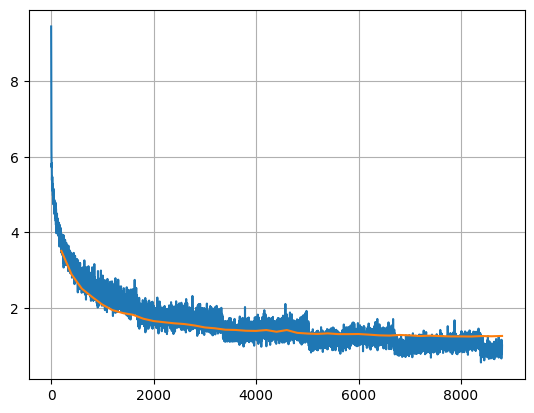

In [ ]:
plt.plot([i["step"] for i in record["train"]], [i["loss"] for i in record["train"]], label="train")
plt.plot([i["step"] for i in record["val"]], [i["loss"] for i in record["val"]], label="val")
plt.grid()
plt.show()

## 推理

- 接下来进行翻译推理，并作出注意力的热度图

In [ ]:
!ls checkpoints/translate-seq2seq

ls: cannot access 'checkpoints/translate-seq2seq': No such file or directory


In [ ]:
# 加载模型权重（load checkpoints），可以用于部署上线或本地测试
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))  # 新建一个与训练时结构一致的模型对象
model.load_state_dict(torch.load(f"best.ckpt", weights_only=True, map_location="cpu"))  # 加载保存在文件中的最佳模型权重

class Translator:
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        self.model = model
        self.model.eval()  # 切换到评估/推理（验证）模式，关闭 Dropout、BatchNorm 等训练特有行为
        self.src_tokenizer = src_tokenizer  # 源语言分词器
        self.trg_tokenizer = trg_tokenizer  # 目标语言分词器

    def draw_attention_map(self, scores, src_words_list, trg_words_list):
        """
        绘制注意力热力图，用于可视化源语言与翻译过程中的目标语言之间的关联关系。

        Args:
            - scores (numpy.ndarray): 注意力分数矩阵，shape = [源序列长度, 目标序列长度]
            - src_words_list (List[str]): 源句子词序列
            - trg_words_list (List[str]): 目标句子词序列
        """
        plt.matshow(scores.T, cmap='viridis')  # 显示注意力分数值的热图（矩阵转置以确保 X 轴和 Y 轴的方向与词对应）
        ax = plt.gca()  # 获取当前坐标轴对象

        # 在每个格子里标注分数的小数值，便于精细观察各单词间的注意力
        for i in range(scores.shape[0]):  # 遍历所有源位置（横轴）
            for j in range(scores.shape[1]):  # 遍历所有目标位置（纵轴）
                ax.text(j, i, f'{scores[i, j]:.2f}', ha='center', va='center', color='k')  # 分数格式化到小数点后2位

        plt.xticks(range(scores.shape[0]), src_words_list)  # X轴标记为源语言单词
        plt.yticks(range(scores.shape[1]), trg_words_list)  # Y轴标记为目标语言单词
        plt.show()

    def __call__(self, sentence):
        # 1. 首先对原始输入句子进行预处理（如标点处理、小写等：视 preprocess_sentence 的具体实现而定）
        sentence = preprocess_sentence(sentence)

        # 2. 使用源语言分词器进行分词、编码为索引ID序列，并进行必要的padding、添加BOS/EOS，并返回 mask
        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],        # 输入为分好词的句子列表（只包含一个句子）
            padding_first=True,        # padding放在前面
            add_bos=True,              # 添加 <bos> 开头
            add_eos=True,              # 添加 <eos> 结尾
            return_mask=True,          # 返回pad mask，用以注意力或编码检测
        )
        # 3. 转化为tensor；long/int64类型以用于Embedding等模型层
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64)

        # 4. 调用模型的 infer 推理接口，返回预测出来的目标语言的token索引序列，以及注意力分数
        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask)

        # 5. 将预测ID序列转回目标语言自然文字（split=True每个token独立成单词，remove_eos=False保留结尾<EOS>用于界定终止）
        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0]

        # 6. 为了绘制注意力图，将输入的token id的序列再通过tokenizer decode回原始的词字符串
        src_decoded = self.src_tokenizer.decode(
            encoder_input.tolist(),
            split=True,       # 返回每个token分词
            remove_bos=False, # 不去除开始符号
            remove_eos=False  # 不去除结束符号
        )[0]

        # 7. 绘制注意力热力图（不同目标词对源词的注意分布可视化）
        self.draw_attention_map(
            scores.squeeze(0).numpy(),  # 移除batch维度，转成numpy数组
            src_decoded,                # 注意力图的横轴：源句子分词
            trg_sentence                # 注意力图的纵轴：预测目标句子分词
        )
        # 8. 返回最终的预测翻译句子（通常去掉最后的EOS token）
        return " ".join(trg_sentence[:-1])


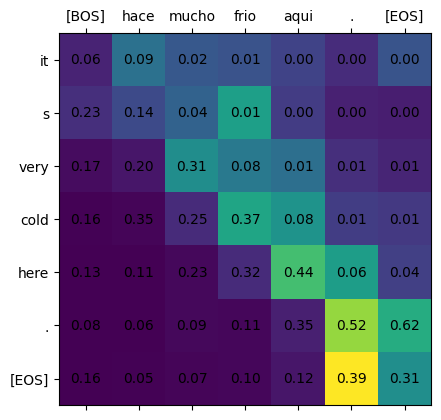

'it s very cold here .'

In [ ]:
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)
translator('hace mucho frio aqui .')

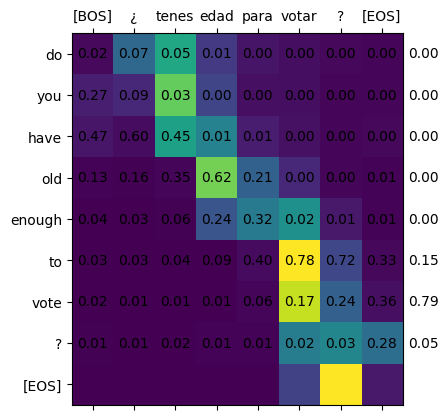

'do you have old enough to vote ?'

In [ ]:
translator(u'¿Tenés edad para votar?')

In [ ]:
# 初始化Seq2Seq模型对象（输入和输出词表的大小分别为源和目标词表大小）
model = Sequence2Sequence(len(src_word2idx), len(trg_word2idx))
# 从保存的模型文件加载最佳训练权重至模型
model.load_state_dict(torch.load(f"./checkpoints/translate-seq2seq/best.ckpt", map_location="cpu"))

class Translator:
    """
    用于序列到序列神经机器翻译模型的推理/翻译器类。
    支持调用方法(即 translator(sentence))直接完成句子翻译。
    """
    def __init__(self, model, src_tokenizer, trg_tokenizer):
        """
        :param model: 已训练好的 Seq2Seq 神经网络模型
        :param src_tokenizer: 源语言分词器
        :param trg_tokenizer: 目标语言分词器
        """
        self.model = model
        self.model.eval() # 进入评估/推理模式，禁用dropout等，仅做前向传播
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer

    def __call__(self, sentence):
        """
        实现 __call__，可直接用 translator(...) 方式取得翻译结果
        :param sentence: 输入要翻译的源语言句子（字符串）
        :return: 翻译好的目标语言自然句文本
        """
        # 1. 句子预处理（通常包括小写化、标点标准化、清理等）
        sentence = preprocess_sentence(sentence) # 预处理句子，如标点符号处理等

        # 2. 用分词器分词，并编码为id，添加padding、BOS/EOS等，生成输入张量及对应attention mask
        encoder_input, attn_mask = self.src_tokenizer.encode(
            [sentence.split()],       # 输入需要分词后的句子列表，此处只含1句
            padding_first=True,       # padding添加在序列前部
            add_bos=True,             # 添加<bos>符号
            add_eos=True,             # 添加<eos>符号
            return_mask=True,         # 返回对应的padding mask
        )
        # 3. 转为PyTorch张量（int64类型，适配后续Embedding/模型输入等）
        encoder_input = torch.Tensor(encoder_input).to(dtype=torch.int64)

        # 4. 用模型的infer接口进行推理，得到预测的目标语言token id序列及attention分数等
        preds, scores = model.infer(encoder_input=encoder_input, attn_mask=attn_mask)

        # 5. 把预测id序列转回实际目标句子的分词文本（保留<eos>作为结尾标识）
        trg_sentence = self.trg_tokenizer.decode([preds], split=True, remove_eos=False)[0]

        # 6. 返回翻译结果字符串，通常去除结尾的<EOS>符号后拼接输出
        return " ".join(trg_sentence[:-1])

from nltk.translate.bleu_score import sentence_bleu

def evaluate_bleu_on_test_set(test_data, translator):
    """
    在测试集上评估平均BLEU分数
    :param test_data: 测试集数据（列表，每个元素为 ：(源语言原句, 目标语言参考译文) ），即[(src_sentence, ref_translations), ...]
    :param translator: 翻译器对象（Translator实例）
    :return: test set的平均BLEU分数
    """
    total_bleu = 0.0  # 累加每个样本的BLEU分
    num_samples = len(test_data)  # 测试集样本数

    # 遍历测试集中的每个句子（包含源句和参考译文）
    for src_sentence, ref_translations in test_data:
        # 利用Translator得到候选翻译
        candidate_translation = translator(src_sentence)

        # 计算该句的BLEU分（此处对所有单句采用1-gram，即unigram精度；可更改weights参数以兼容长ngram）
        bleu_score = sentence_bleu([ref_translations.split()],     # 参考译文(分词list)的list
                                   candidate_translation.split(),  # 预测译文(分词list)
                                   weights=(1, 0, 0, 0))           # 仅计unigram精度
        total_bleu += bleu_score     # 累加

        # 可选: 打印每个句子的bleu细节信息
        # print(f"Source: {src_sentence}")
        # print(f"Reference: {ref_translations}")
        # print(f"Candidate: {candidate_translation}")
        # print(f"BLEU: {bleu_score:.4f}")
        # print("-" * 50)
        # i += 1
        # if i > 10: break # 如仅调试，限制前10

    # 计算平均BLEU分
    avg_bleu = total_bleu / num_samples if num_samples > 0 else 0.0
    return avg_bleu

# 实例化translate对象，cpu模式（如需gpu推理，可换成.cuda()）
translator = Translator(model.cpu(), src_tokenizer, trg_tokenizer)

# 计算并返回test_ds的平均BLEU分数
evaluate_bleu_on_test_set(test_ds, translator)

/tmp/ipykernel_418/472989537.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"./checkpoints/translate-seq2seq/best.ckpt", map_location=

0.7061088734375165